In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/projectburak/sonuygundegil/uygundegilFALCON/08450.jpg
/kaggle/input/datasets/projectburak/sonuygundegil/uygundegilFALCON/mls398.jpg
/kaggle/input/datasets/projectburak/sonuygundegil/uygundegilFALCON/9999951_00000_d_0000023.jpg
/kaggle/input/datasets/projectburak/sonuygundegil/uygundegilFALCON/9999973_00000_d_0000028.jpg
/kaggle/input/datasets/projectburak/sonuygundegil/uygundegilFALCON/mhger582.jpg
/kaggle/input/datasets/projectburak/sonuygundegil/uygundegilFALCON/tarım077.jpg
/kaggle/input/datasets/projectburak/sonuygundegil/uygundegilFALCON/9999938_00000_d_0000034.jpg
/kaggle/input/datasets/projectburak/sonuygundegil/uygundegilFALCON/play466.jpg
/kaggle/input/datasets/projectburak/sonuygundegil/uygundegilFALCON/dfgh569.jpg
/kaggle/input/datasets/projectburak/sonuygundegil/uygundegilFALCON/0000063_05000_d_0000006.jpg
/kaggle/input/datasets/projectburak/sonuygundegil/uygundegilFALCON/mhger475.jpg
/kaggle/input/datasets/projectburak/sonuygundegil/uygundegilFALCON/

In [2]:
# CELL 1 - TEMEL KÜTÜPHANELER

import os, random, time, glob
import numpy as np
import pandas as pd

print("Temel kütüphaneler yüklendi.")
print(f"os modülü: {type(os)}")
print(f"random modülü: {type(random)}")
print(f"time modülü: {type(time)}")
print(f"glob modülü: {type(glob)}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")

Temel kütüphaneler yüklendi.
os modülü: <class 'module'>
random modülü: <class 'module'>
time modülü: <class 'module'>
glob modülü: <class 'module'>
NumPy: 2.0.2
Pandas: 2.3.3


In [3]:
# CELL 2 - TORCH & TORCHVISION

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

print(f"PyTorch: {torch.__version__}")
print(f"CUDA kullanılabilir mi?: {torch.cuda.is_available()}")
print(f"nn modülü: {type(nn)}")
print(f"F modülü: {type(F)}")
print(f"Dataset sınıfı: {Dataset}")
print(f"DataLoader sınıfı: {DataLoader}")
print(f"WeightedRandomSampler sınıfı: {WeightedRandomSampler}")
print(f"AdamW sınıfı: {AdamW}")
print(f"CosineAnnealingLR sınıfı: {CosineAnnealingLR}")

PyTorch: 2.10.0+cu128
CUDA kullanılabilir mi?: True
nn modülü: <class 'module'>
F modülü: <class 'module'>
Dataset sınıfı: <class 'torch.utils.data.dataset.Dataset'>
DataLoader sınıfı: <class 'torch.utils.data.dataloader.DataLoader'>
WeightedRandomSampler sınıfı: <class 'torch.utils.data.sampler.WeightedRandomSampler'>
AdamW sınıfı: <class 'torch.optim.adamw.AdamW'>
CosineAnnealingLR sınıfı: <class 'torch.optim.lr_scheduler.CosineAnnealingLR'>


In [4]:
# CELL 3 - GÖRSEL & DİĞER KÜTÜPHANELER

from torchvision import transforms
from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

print("Görsel ve metrik kütüphaneler yüklendi.")
print(f"transforms modülü: {type(transforms)}")
print(f"efficientnet_b2 fonksiyonu: {efficientnet_b2}")
print(f"EfficientNet_B2_Weights: {EfficientNet_B2_Weights}")
print(f"PIL Image modülü: {type(Image)}")
print(f"train_test_split fonksiyonu: {train_test_split}")
print(f"classification_report fonksiyonu: {classification_report}")
print(f"confusion_matrix fonksiyonu: {confusion_matrix}")
print(f"f1_score fonksiyonu: {f1_score}")

Görsel ve metrik kütüphaneler yüklendi.
transforms modülü: <class 'module'>
efficientnet_b2 fonksiyonu: <function efficientnet_b2 at 0x7d7d8ee93d80>
EfficientNet_B2_Weights: <enum 'EfficientNet_B2_Weights'>
PIL Image modülü: <class 'module'>
train_test_split fonksiyonu: <function train_test_split at 0x7d7d7f4942c0>
classification_report fonksiyonu: <function classification_report at 0x7d7d7fd35940>
confusion_matrix fonksiyonu: <function confusion_matrix at 0x7d7d7fd345e0>
f1_score fonksiyonu: <function f1_score at 0x7d7d7fd34d60>


In [5]:
# CELL 4 - SEED & DETERMİNİZM

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Seed ayarlandı: 42")
print(f"SEED değişken tipi: {type(SEED)}")
print(f"torch.backends.cudnn.deterministic: {torch.backends.cudnn.deterministic}")
print(f"torch.backends.cudnn.benchmark: {torch.backends.cudnn.benchmark}")

Seed ayarlandı: 42
SEED değişken tipi: <class 'int'>
torch.backends.cudnn.deterministic: True
torch.backends.cudnn.benchmark: False


In [6]:
# CELL 5 - DEVICE KONTROLÜ

import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {device}")
print(f"device tipi: {type(device)}")

if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA device count: {torch.cuda.device_count()}")
    print(f"CUDA current device: {torch.cuda.current_device()}")
else:
    print("GPU bulunamadı, CPU kullanılacak.")

Device: cuda
device tipi: <class 'torch.device'>
GPU: Tesla T4
CUDA device count: 2
CUDA current device: 0


In [7]:
# CELL 6 - FOCAL LOSS TANIMI

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma

    def forward(self, outputs, targets):
        ce_loss = F.cross_entropy(outputs, targets, reduction="none")
        pt = torch.exp(-ce_loss)
        focal = ((1 - pt) ** self.gamma) * ce_loss
        return focal.mean()

criterion = FocalLoss(gamma=2.0)

print("FocalLoss tanımlandı.")
print(f"criterion tipi: {type(criterion)}")
print(f"gamma değeri: {criterion.gamma}")

FocalLoss tanımlandı.
criterion tipi: <class '__main__.FocalLoss'>
gamma değeri: 2.0


In [8]:
# CELL 7 - FOREST DOSYALARINI TARA

forest_dir = "/kaggle/input/datasets/projectburak/sonuygun"

image_extensions = ("*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG")
forest_paths = []

for ext in image_extensions:
    forest_paths.extend(glob.glob(os.path.join(forest_dir, "**", ext), recursive=True))

forest_paths = sorted(forest_paths)

print(f"Forest klasörü: {forest_dir}")
print(f"forest_dir tipi: {type(forest_dir)}")
print(f"forest_paths tipi: {type(forest_paths)}")
print(f"Forest görsel sayısı: {len(forest_paths)}")

if len(forest_paths) > 0:
    print(f"İlk forest görseli: {forest_paths[0]}")
else:
    print("UYARI: Forest görseli bulunamadı.")

Forest klasörü: /kaggle/input/datasets/projectburak/sonuygun
forest_dir tipi: <class 'str'>
forest_paths tipi: <class 'list'>
Forest görsel sayısı: 6196
İlk forest görseli: /kaggle/input/datasets/projectburak/sonuygun/uygunsonfalcon 2/001.jpg


In [9]:
# CELL 8 - NON-FOREST DOSYALARINI TARA

nonforest_dir = "/kaggle/input/datasets/projectburak/sonuygundegil"

nonforest_paths = []

for ext in image_extensions:
    nonforest_paths.extend(glob.glob(os.path.join(nonforest_dir, "**", ext), recursive=True))

nonforest_paths = sorted(nonforest_paths)

print(f"Non-forest klasörü: {nonforest_dir}")
print(f"nonforest_dir tipi: {type(nonforest_dir)}")
print(f"nonforest_paths tipi: {type(nonforest_paths)}")
print(f"Non-forest görsel sayısı: {len(nonforest_paths)}")

if len(nonforest_paths) > 0:
    print(f"İlk non-forest görseli: {nonforest_paths[0]}")
else:
    print("UYARI: Non-forest görseli bulunamadı.")

Non-forest klasörü: /kaggle/input/datasets/projectburak/sonuygundegil
nonforest_dir tipi: <class 'str'>
nonforest_paths tipi: <class 'list'>
Non-forest görsel sayısı: 28482
İlk non-forest görseli: /kaggle/input/datasets/projectburak/sonuygundegil/uygundegilFALCON/0000000_00098_d_0000001.jpg


In [10]:
# CELL 9 - LABEL ATAMALARI & BİRLEŞTİRME

forest_labels = [0] * len(forest_paths)
nonforest_labels = [1] * len(nonforest_paths)

all_paths = forest_paths + nonforest_paths
all_labels = forest_labels + nonforest_labels

class_to_idx = {"forest": 0, "non_forest": 1}

print(f"Toplam görsel: {len(all_paths)}")
print(f"Forest (0): {all_labels.count(0)}")
print(f"Non-forest (1): {all_labels.count(1)}")
print(f"all_paths tipi: {type(all_paths)}")
print(f"all_labels tipi: {type(all_labels)}")
print(f"class_to_idx: {class_to_idx}")

if len(all_paths) > 0:
    print(f"İlk path: {all_paths[0]}")
    print(f"İlk label: {all_labels[0]}")

Toplam görsel: 34678
Forest (0): 6196
Non-forest (1): 28482
all_paths tipi: <class 'list'>
all_labels tipi: <class 'list'>
class_to_idx: {'forest': 0, 'non_forest': 1}
İlk path: /kaggle/input/datasets/projectburak/sonuygun/uygunsonfalcon 2/001.jpg
İlk label: 0


In [11]:
# CELL 10 - TRAIN/VAL/TEST BÖLME

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths, all_labels,
    test_size=0.30,
    random_state=42,
    stratify=all_labels
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels,
    test_size=0.50,
    random_state=42,
    stratify=temp_labels
)

print(f"Train: {len(train_paths)}")
print(f"Val:   {len(val_paths)}")
print(f"Test:  {len(test_paths)}")
print(f"train_paths tipi: {type(train_paths)}")
print(f"train_labels tipi: {type(train_labels)}")
print(f"Train label dağılımı: {np.bincount(train_labels)}")
print(f"Val label dağılımı:   {np.bincount(val_labels)}")
print(f"Test label dağılımı:  {np.bincount(test_labels)}")

Train: 24274
Val:   5202
Test:  5202
train_paths tipi: <class 'list'>
train_labels tipi: <class 'list'>
Train label dağılımı: [ 4337 19937]
Val label dağılımı:   [ 929 4273]
Test label dağılımı:  [ 930 4272]


In [12]:
# CELL 11 - CUSTOM DATASET SINIFI

Image.MAX_IMAGE_PIXELS = None

class ForestDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

print("ForestDataset tanımlandı.")
print(f"ForestDataset tipi: {type(ForestDataset)}")
print(f"class_to_idx: {class_to_idx}")
print(f"Image.MAX_IMAGE_PIXELS: {Image.MAX_IMAGE_PIXELS}")

ForestDataset tanımlandı.
ForestDataset tipi: <class 'type'>
class_to_idx: {'forest': 0, 'non_forest': 1}
Image.MAX_IMAGE_PIXELS: None


In [13]:
# CELL 12 - TRANSFORM TANIMLARI

train_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.15,
        hue=0.03
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transform'lar tanımlandı.")
print(f"train_transform tipi: {type(train_transform)}")
print(f"val_test_transform tipi: {type(val_test_transform)}")
print(f"Train transform adım sayısı: {len(train_transform.transforms)}")
print(f"Val/Test transform adım sayısı: {len(val_test_transform.transforms)}")

Transform'lar tanımlandı.
train_transform tipi: <class 'torchvision.transforms.transforms.Compose'>
val_test_transform tipi: <class 'torchvision.transforms.transforms.Compose'>
Train transform adım sayısı: 6
Val/Test transform adım sayısı: 3


In [14]:
# CELL 13 - DATASET NESNELERI

train_dataset = ForestDataset(
    paths=train_paths,
    labels=train_labels,
    transform=train_transform
)

val_dataset = ForestDataset(
    paths=val_paths,
    labels=val_labels,
    transform=val_test_transform
)

test_dataset = ForestDataset(
    paths=test_paths,
    labels=test_labels,
    transform=val_test_transform
)

train_targets = train_labels

print(f"Train dataset: {len(train_dataset)}")
print(f"Val dataset:   {len(val_dataset)}")
print(f"Test dataset:  {len(test_dataset)}")
print(f"train_dataset tipi: {type(train_dataset)}")
print(f"val_dataset tipi: {type(val_dataset)}")
print(f"test_dataset tipi: {type(test_dataset)}")
print(f"train_targets tipi: {type(train_targets)}")

Train dataset: 24274
Val dataset:   5202
Test dataset:  5202
train_dataset tipi: <class '__main__.ForestDataset'>
val_dataset tipi: <class '__main__.ForestDataset'>
test_dataset tipi: <class '__main__.ForestDataset'>
train_targets tipi: <class 'list'>


In [15]:
# CELL 14 - WEIGHTED SAMPLER

g_sampler = torch.Generator()
g_sampler.manual_seed(42)

g_loader = torch.Generator()
g_loader.manual_seed(42)

class_counts = np.bincount(train_targets)
class_weights = 1.0 / class_counts
sample_weights = class_weights[train_targets]

sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True,
    generator=g_sampler
)

print("Sampler oluşturuldu.")
print(f"class_counts tipi: {type(class_counts)}, shape: {class_counts.shape}")
print(f"class_weights tipi: {type(class_weights)}, shape: {class_weights.shape}")
print(f"sample_weights tipi: {type(sample_weights)}, shape: {sample_weights.shape}")
print(f"Class weights: forest={class_weights[0]:.4f}, non_forest={class_weights[1]:.4f}")
print(f"Sampler tipi: {type(sampler)}")

Sampler oluşturuldu.
class_counts tipi: <class 'numpy.ndarray'>, shape: (2,)
class_weights tipi: <class 'numpy.ndarray'>, shape: (2,)
sample_weights tipi: <class 'numpy.ndarray'>, shape: (24274,)
Class weights: forest=0.0002, non_forest=0.0001
Sampler tipi: <class 'torch.utils.data.sampler.WeightedRandomSampler'>


In [16]:
# CELL 15 - DATALOADER'LAR

BATCH_SIZE = 32
num_workers = 2
pin_memory = (device.type == "cuda")

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    sampler=sampler,
    num_workers=num_workers,
    pin_memory=pin_memory,
    worker_init_fn=seed_worker,
    generator=g_loader
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
    worker_init_fn=seed_worker
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
    worker_init_fn=seed_worker
)

print("DataLoader'lar oluşturuldu.")
print(f"Batch size: {BATCH_SIZE}")
print(f"pin_memory: {pin_memory}")
print(f"Train batch sayısı: {len(train_loader)}")
print(f"Val batch sayısı:   {len(val_loader)}")
print(f"Test batch sayısı:  {len(test_loader)}")

DataLoader'lar oluşturuldu.
Batch size: 32
pin_memory: True
Train batch sayısı: 759
Val batch sayısı:   163
Test batch sayısı:  163


In [17]:
# CELL 16 - MODEL YÜKLEME

weights = EfficientNet_B2_Weights.IMAGENET1K_V1
model = efficientnet_b2(weights=weights)

in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, 2)

model = model.to(device)

total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Model yüklendi.")
print(f"weights tipi: {type(weights)}")
print(f"model tipi: {type(model)}")
print(f"in_features: {in_features}")
print(f"Classifier son katman: {model.classifier[1]}")
print(f"Toplam parametre: {total:,}")
print(f"Başlangıç eğitilebilir parametre: {trainable:,}")

Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 145MB/s]


Model yüklendi.
weights tipi: <enum 'EfficientNet_B2_Weights'>
model tipi: <class 'torchvision.models.efficientnet.EfficientNet'>
in_features: 1408
Classifier son katman: Linear(in_features=1408, out_features=2, bias=True)
Toplam parametre: 7,703,812
Başlangıç eğitilebilir parametre: 7,703,812


In [18]:
# CELL 17 - STAGE 1 HAZIRLIK

for param in model.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

stage1_optimizer = AdamW(
    model.classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

stage1_scheduler = CosineAnnealingLR(
    stage1_optimizer,
    T_max=10
)

best_val_f1 = -1.0
best_checkpoint_path = "/kaggle/working/b2_best_model.pth"
log_path = "/kaggle/working/b2_training_log.csv"
training_logs = []

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Stage 1 hazır.")
print(f"stage1_optimizer tipi: {type(stage1_optimizer)}")
print(f"stage1_scheduler tipi: {type(stage1_scheduler)}")
print(f"best_checkpoint_path: {best_checkpoint_path}")
print(f"log_path: {log_path}")
print(f"training_logs tipi: {type(training_logs)}")
print(f"Eğitilebilir parametre: {trainable:,}")

Stage 1 hazır.
stage1_optimizer tipi: <class 'torch.optim.adamw.AdamW'>
stage1_scheduler tipi: <class 'torch.optim.lr_scheduler.CosineAnnealingLR'>
best_checkpoint_path: /kaggle/working/b2_best_model.pth
log_path: /kaggle/working/b2_training_log.csv
training_logs tipi: <class 'list'>
Eğitilebilir parametre: 2,818


In [19]:
# CELL 18 - STAGE 1 EĞİTİM DÖNGÜSÜ

def run_one_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, all_preds, all_targets = 0.0, [], []

    for images, targets in loader:
        images = images.to(device)
        targets = torch.as_tensor(targets, dtype=torch.long, device=device)

        with torch.set_grad_enabled(is_train):
            outputs = model(images)
            loss = criterion(outputs, targets)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * images.size(0)
        all_preds.extend(outputs.argmax(1).detach().cpu().numpy())
        all_targets.extend(targets.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = np.mean(np.array(all_preds) == np.array(all_targets))
    macro_f1 = f1_score(all_targets, all_preds, average="macro")
    forest_f1 = f1_score(all_targets, all_preds, labels=[0], average="macro")
    return avg_loss, acc, macro_f1, forest_f1

for epoch in range(1, 11):
    start_time = time.time()
    train_loss, _, _, _ = run_one_epoch(model, train_loader, criterion, stage1_optimizer)
    val_loss, val_acc, val_macro_f1, val_forest_f1 = run_one_epoch(model, val_loader, criterion)
    stage1_scheduler.step()
    time_sec = time.time() - start_time

    training_logs.append({
        "stage": "stage1", "epoch": epoch, "train_loss": train_loss,
        "val_loss": val_loss, "val_accuracy": val_acc,
        "val_macro_f1": val_macro_f1, "val_forest_f1": val_forest_f1,
        "time_sec": time_sec
    })

    if val_forest_f1 > best_val_f1:
        best_val_f1 = val_forest_f1
        torch.save({
            "model_state_dict": model.state_dict(), "epoch": epoch,
            "val_f1": val_forest_f1, "class_to_idx": class_to_idx
        }, best_checkpoint_path)

    pd.DataFrame(training_logs).to_csv(log_path, index=False)
    torch.cuda.empty_cache()
    print(f"[S1 E{epoch}] train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
          f"val_acc={val_acc:.4f} val_forest_f1={val_forest_f1:.4f} time={time_sec:.1f}s")

print("Stage 1 tamamlandı.")
print(f"En iyi val_forest_f1: {best_val_f1:.4f}")

[S1 E1] train_loss=0.0355 val_loss=0.0134 val_acc=0.9850 val_forest_f1=0.9584 time=463.3s
[S1 E2] train_loss=0.0278 val_loss=0.0127 val_acc=0.9810 val_forest_f1=0.9472 time=431.0s
[S1 E3] train_loss=0.0296 val_loss=0.0113 val_acc=0.9844 val_forest_f1=0.9566 time=413.8s
[S1 E4] train_loss=0.0296 val_loss=0.0137 val_acc=0.9823 val_forest_f1=0.9517 time=430.7s
[S1 E5] train_loss=0.0276 val_loss=0.0147 val_acc=0.9810 val_forest_f1=0.9484 time=449.5s
[S1 E6] train_loss=0.0270 val_loss=0.0115 val_acc=0.9854 val_forest_f1=0.9597 time=409.0s
[S1 E7] train_loss=0.0269 val_loss=0.0117 val_acc=0.9842 val_forest_f1=0.9568 time=440.5s
[S1 E8] train_loss=0.0259 val_loss=0.0114 val_acc=0.9846 val_forest_f1=0.9575 time=441.4s
[S1 E9] train_loss=0.0259 val_loss=0.0143 val_acc=0.9819 val_forest_f1=0.9511 time=427.7s
[S1 E10] train_loss=0.0238 val_loss=0.0110 val_acc=0.9858 val_forest_f1=0.9607 time=423.4s
Stage 1 tamamlandı.
En iyi val_forest_f1: 0.9607


In [20]:
# CELL 19 - STAGE 2 HAZIRLIK

checkpoint = torch.load(
    best_checkpoint_path,
    map_location=device,
    weights_only=False
)

model.load_state_dict(checkpoint["model_state_dict"])

for param in model.parameters():
    param.requires_grad = False

for param in model.features[-3:].parameters():
    param.requires_grad = True

for param in model.classifier.parameters():
    param.requires_grad = True

stage2_optimizer = AdamW([
    {"params": model.features[-3:].parameters(), "lr": 1e-5},
    {"params": model.classifier.parameters(), "lr": 1e-4},
], weight_decay=1e-4)

stage2_scheduler = CosineAnnealingLR(
    stage2_optimizer,
    T_max=20
)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Stage 2 hazır.")
print(f"checkpoint tipi: {type(checkpoint)}")
print(f"Checkpoint epoch: {checkpoint['epoch']}")
print(f"Checkpoint val_f1: {checkpoint['val_f1']:.4f}")
print(f"stage2_optimizer tipi: {type(stage2_optimizer)}")
print(f"stage2_scheduler tipi: {type(stage2_scheduler)}")
print(f"Eğitilebilir parametre: {trainable:,}")

Stage 2 hazır.
checkpoint tipi: <class 'dict'>
Checkpoint epoch: 10
Checkpoint val_f1: 0.9607
stage2_optimizer tipi: <class 'torch.optim.adamw.AdamW'>
stage2_scheduler tipi: <class 'torch.optim.lr_scheduler.CosineAnnealingLR'>
Eğitilebilir parametre: 6,285,948


In [21]:
# CELL 20 - STAGE 2 EĞİTİM DÖNGÜSÜ

stage2_start_epoch = 11
stage2_end_epoch = 30

for epoch in range(stage2_start_epoch, stage2_end_epoch + 1):
    start_time = time.time()

    train_loss, _, _, _ = run_one_epoch(
        model, train_loader, criterion, stage2_optimizer
    )

    val_loss, val_acc, val_macro_f1, val_forest_f1 = run_one_epoch(
        model, val_loader, criterion
    )

    stage2_scheduler.step()
    time_sec = time.time() - start_time

    training_logs.append({
        "stage": "stage2",
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_accuracy": val_acc,
        "val_macro_f1": val_macro_f1,
        "val_forest_f1": val_forest_f1,
        "time_sec": time_sec
    })

    if val_forest_f1 > best_val_f1:
        best_val_f1 = val_forest_f1
        torch.save({
            "model_state_dict": model.state_dict(),
            "epoch": epoch,
            "val_f1": val_forest_f1,
            "class_to_idx": class_to_idx
        }, best_checkpoint_path)

    pd.DataFrame(training_logs).to_csv(log_path, index=False)
    torch.cuda.empty_cache()

    print(f"[S2 E{epoch}] train_loss={train_loss:.4f} "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} "
          f"val_forest_f1={val_forest_f1:.4f} time={time_sec:.1f}s")

print("Stage 2 tamamlandı.")
print(f"En iyi val_forest_f1: {best_val_f1:.4f}")
print(f"Log dosyası: {log_path}")
print(f"Checkpoint dosyası: {best_checkpoint_path}")

[S2 E11] train_loss=0.0188 val_loss=0.0070 val_acc=0.9902 val_forest_f1=0.9730 time=430.3s
[S2 E12] train_loss=0.0122 val_loss=0.0049 val_acc=0.9950 val_forest_f1=0.9861 time=428.6s
[S2 E13] train_loss=0.0099 val_loss=0.0048 val_acc=0.9938 val_forest_f1=0.9830 time=418.7s
[S2 E14] train_loss=0.0083 val_loss=0.0044 val_acc=0.9944 val_forest_f1=0.9845 time=434.6s
[S2 E15] train_loss=0.0066 val_loss=0.0034 val_acc=0.9962 val_forest_f1=0.9893 time=440.2s
[S2 E16] train_loss=0.0055 val_loss=0.0038 val_acc=0.9946 val_forest_f1=0.9850 time=438.5s
[S2 E17] train_loss=0.0045 val_loss=0.0032 val_acc=0.9962 val_forest_f1=0.9892 time=438.6s
[S2 E18] train_loss=0.0037 val_loss=0.0033 val_acc=0.9956 val_forest_f1=0.9876 time=450.8s
[S2 E19] train_loss=0.0029 val_loss=0.0034 val_acc=0.9954 val_forest_f1=0.9871 time=435.8s
[S2 E20] train_loss=0.0032 val_loss=0.0034 val_acc=0.9960 val_forest_f1=0.9887 time=450.2s
[S2 E21] train_loss=0.0026 val_loss=0.0032 val_acc=0.9960 val_forest_f1=0.9887 time=444.5s

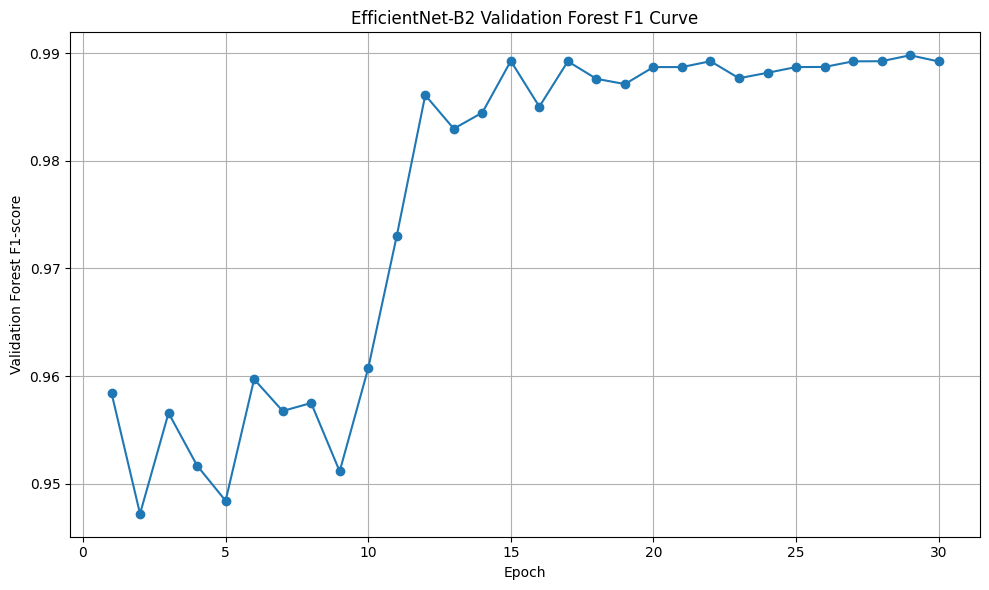

F1 eğrisi kaydedildi.
log_df tipi: <class 'pandas.core.frame.DataFrame'>
log_df shape: (30, 8)
F1 grafik dosyası: /kaggle/working/b2_val_forest_f1_curve.png
En yüksek val_forest_f1: 0.9898
En iyi epoch: 29


In [22]:
# CELL 21 - VAL FOREST F1 GRAFİĞİ

log_df = pd.DataFrame(training_logs)
f1_curve_path = "/kaggle/working/b2_val_forest_f1_curve.png"

plt.figure(figsize=(10, 6))
plt.plot(log_df["epoch"], log_df["val_forest_f1"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Validation Forest F1-score")
plt.title("EfficientNet-B2 Validation Forest F1 Curve")
plt.grid(True)
plt.tight_layout()
plt.savefig(f1_curve_path, dpi=300)
plt.show()

print("F1 eğrisi kaydedildi.")
print(f"log_df tipi: {type(log_df)}")
print(f"log_df shape: {log_df.shape}")
print(f"F1 grafik dosyası: {f1_curve_path}")
print(f"En yüksek val_forest_f1: {log_df['val_forest_f1'].max():.4f}")
print(f"En iyi epoch: {log_df.loc[log_df['val_forest_f1'].idxmax(), 'epoch']}")

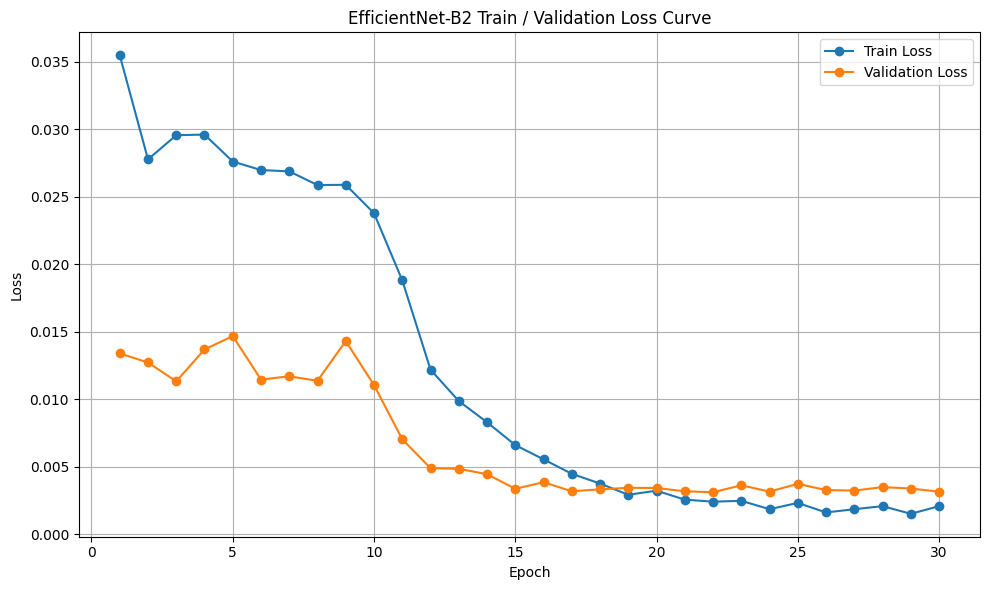

Loss eğrisi kaydedildi.
loss_curve_path: /kaggle/working/b2_loss_curve.png
Minimum train_loss: 0.0015
Minimum val_loss: 0.0031
Son train_loss: 0.0021
Son val_loss: 0.0031


In [23]:
# CELL 22 - LOSS GRAFİĞİ

loss_curve_path = "/kaggle/working/b2_loss_curve.png"

plt.figure(figsize=(10, 6))
plt.plot(log_df["epoch"], log_df["train_loss"], marker="o", label="Train Loss")
plt.plot(log_df["epoch"], log_df["val_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNet-B2 Train / Validation Loss Curve")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(loss_curve_path, dpi=300)
plt.show()

print("Loss eğrisi kaydedildi.")
print(f"loss_curve_path: {loss_curve_path}")
print(f"Minimum train_loss: {log_df['train_loss'].min():.4f}")
print(f"Minimum val_loss: {log_df['val_loss'].min():.4f}")
print(f"Son train_loss: {log_df['train_loss'].iloc[-1]:.4f}")
print(f"Son val_loss: {log_df['val_loss'].iloc[-1]:.4f}")

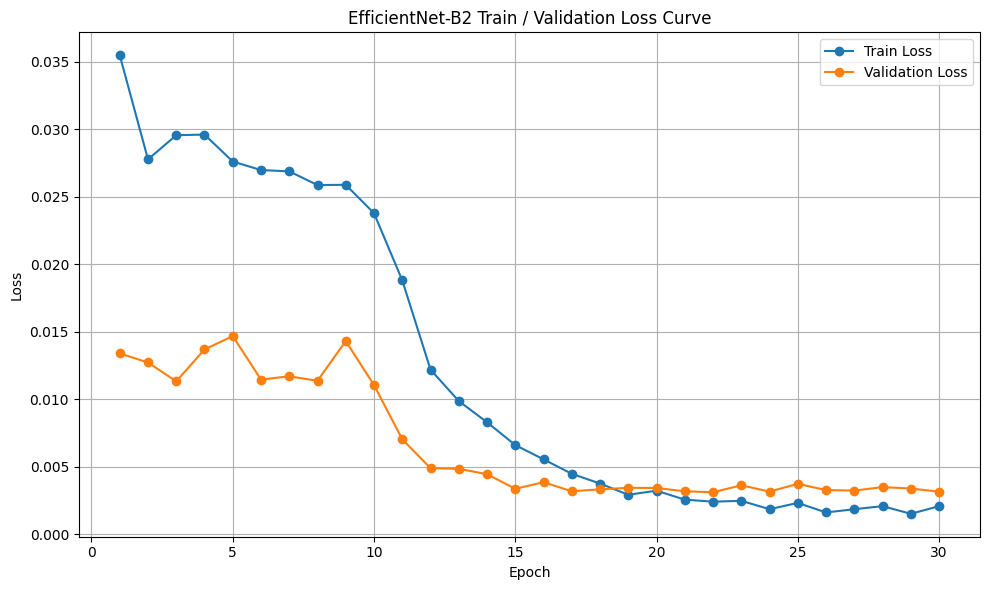

Loss eğrisi kaydedildi.
loss_curve_path: /kaggle/working/b2_loss_curve.png
Minimum train_loss: 0.0015
Minimum val_loss: 0.0031
Son train_loss: 0.0021
Son val_loss: 0.0031


In [24]:
# CELL 22 - LOSS GRAFİĞİ

loss_curve_path = "/kaggle/working/b2_loss_curve.png"

plt.figure(figsize=(10, 6))
plt.plot(log_df["epoch"], log_df["train_loss"], marker="o", label="Train Loss")
plt.plot(log_df["epoch"], log_df["val_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNet-B2 Train / Validation Loss Curve")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(loss_curve_path, dpi=300)
plt.show()

print("Loss eğrisi kaydedildi.")
print(f"loss_curve_path: {loss_curve_path}")
print(f"Minimum train_loss: {log_df['train_loss'].min():.4f}")
print(f"Minimum val_loss: {log_df['val_loss'].min():.4f}")
print(f"Son train_loss: {log_df['train_loss'].iloc[-1]:.4f}")
print(f"Son val_loss: {log_df['val_loss'].iloc[-1]:.4f}")

In [25]:
# CELL 23 - TEST DEĞERLENDİRMESİ

best_checkpoint = torch.load(
    best_checkpoint_path,
    map_location=device,
    weights_only=False
)

model.load_state_dict(best_checkpoint["model_state_dict"])
model.eval()

test_loss, test_acc, test_macro_f1, _ = run_one_epoch(
    model,
    test_loader,
    criterion
)

all_test_preds = []
all_test_targets = []

with torch.no_grad():
    for images, targets in test_loader:
        images = images.to(device)
        targets = torch.as_tensor(targets, dtype=torch.long, device=device)
        outputs = model(images)
        preds = outputs.argmax(1)

        all_test_preds.extend(preds.cpu().numpy())
        all_test_targets.extend(targets.cpu().numpy())

test_report_dict = classification_report(
    all_test_targets,
    all_test_preds,
    target_names=["forest", "non_forest"],
    output_dict=True,
    digits=4
)

forest_precision = test_report_dict["forest"]["precision"]
forest_recall = test_report_dict["forest"]["recall"]
forest_f1 = test_report_dict["forest"]["f1-score"]
nonforest_precision = test_report_dict["non_forest"]["precision"]
nonforest_recall = test_report_dict["non_forest"]["recall"]
nonforest_f1 = test_report_dict["non_forest"]["f1-score"]

print("Test değerlendirmesi tamamlandı.")
print(f"Checkpoint epoch: {best_checkpoint['epoch']}")
print(f"Best Validation Forest F1: {best_checkpoint['val_f1']:.4f}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Macro F1: {test_macro_f1:.4f}")
print(f"Forest Precision/Recall/F1: {forest_precision:.4f} / {forest_recall:.4f} / {forest_f1:.4f}")
print(f"Non-Forest Precision/Recall/F1: {nonforest_precision:.4f} / {nonforest_recall:.4f} / {nonforest_f1:.4f}")

Test değerlendirmesi tamamlandı.
Checkpoint epoch: 29
Best Validation Forest F1: 0.9898
Test Loss: 0.0042
Test Accuracy: 0.9973
Test Macro F1: 0.9954
Forest Precision/Recall/F1: 0.9862 / 0.9989 / 0.9925
Non-Forest Precision/Recall/F1: 0.9998 / 0.9970 / 0.9984


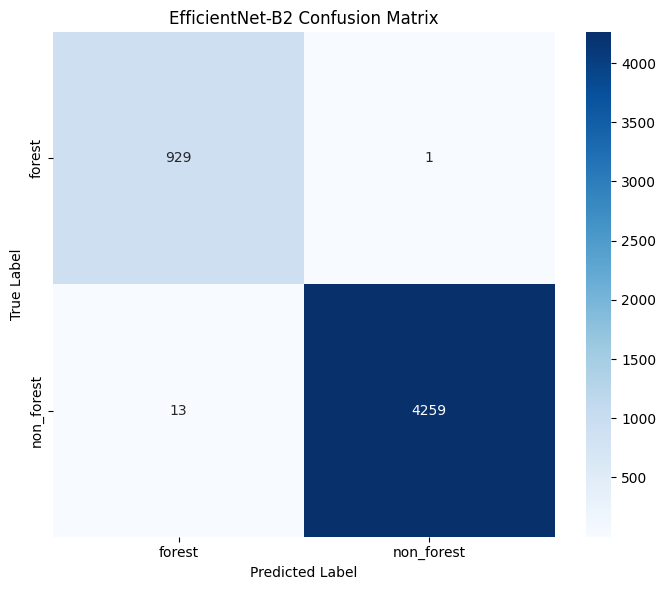

Confusion matrix kaydedildi.
cm tipi: <class 'numpy.ndarray'>
cm shape: (2, 2)
Confusion matrix dosyası: /kaggle/working/b2_confusion_matrix.png
[[ 929    1]
 [  13 4259]]


In [26]:
# CELL 24 - CONFUSION MATRIX

cm = confusion_matrix(all_test_targets, all_test_preds)
confusion_matrix_path = "/kaggle/working/b2_confusion_matrix.png"

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["forest", "non_forest"],
    yticklabels=["forest", "non_forest"]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("EfficientNet-B2 Confusion Matrix")
plt.tight_layout()
plt.savefig(confusion_matrix_path, dpi=300)
plt.show()

print("Confusion matrix kaydedildi.")
print(f"cm tipi: {type(cm)}")
print(f"cm shape: {cm.shape}")
print(f"Confusion matrix dosyası: {confusion_matrix_path}")
print(cm)

In [27]:
# CELL 25 - RAPOR KAYDET

test_report_text = classification_report(
    all_test_targets,
    all_test_preds,
    target_names=["forest", "non_forest"],
    digits=4
)

test_report_path = "/kaggle/working/b2_test_report.txt"

report_content = f"""Model: EfficientNet-B2
Image Size: 260x260
Loss: Focal Loss (gamma=2.0)
Checkpoint Path: {best_checkpoint_path}

Dataset Split:
Train size: {len(train_dataset)}
Validation size: {len(val_dataset)}
Test size: {len(test_dataset)}
Total size: {len(all_paths)}

Class Mapping:
forest = 0
non_forest = 1

Loaded Checkpoint:
Checkpoint epoch: {best_checkpoint["epoch"]}
Best Validation Forest F1: {best_checkpoint["val_f1"]:.4f}

TEST RESULTS:
Test Loss: {test_loss:.4f}
Test Accuracy: {test_acc:.4f}
Test Macro F1: {test_macro_f1:.4f}

Forest Class:
Forest Precision: {forest_precision:.4f}
Forest Recall: {forest_recall:.4f}
Forest F1-score: {forest_f1:.4f}

Non-Forest Class:
Non-Forest Precision: {nonforest_precision:.4f}
Non-Forest Recall: {nonforest_recall:.4f}
Non-Forest F1-score: {nonforest_f1:.4f}

Classification Report:
{test_report_text}
"""

with open(test_report_path, "w", encoding="utf-8") as f:
    f.write(report_content)

print(test_report_text)
print("Tüm çıktılar kaydedildi.")
print("İşlem tamamlandı.")
print(f"Model dosyası: {best_checkpoint_path}")
print(f"Log dosyası: {log_path}")
print(f"F1 grafiği: {f1_curve_path}")
print(f"Loss grafiği: {loss_curve_path}")
print(f"Confusion matrix: {confusion_matrix_path}")
print(f"Test raporu: {test_report_path}")

              precision    recall  f1-score   support

      forest     0.9862    0.9989    0.9925       930
  non_forest     0.9998    0.9970    0.9984      4272

    accuracy                         0.9973      5202
   macro avg     0.9930    0.9979    0.9954      5202
weighted avg     0.9973    0.9973    0.9973      5202

Tüm çıktılar kaydedildi.
İşlem tamamlandı.
Model dosyası: /kaggle/working/b2_best_model.pth
Log dosyası: /kaggle/working/b2_training_log.csv
F1 grafiği: /kaggle/working/b2_val_forest_f1_curve.png
Loss grafiği: /kaggle/working/b2_loss_curve.png
Confusion matrix: /kaggle/working/b2_confusion_matrix.png
Test raporu: /kaggle/working/b2_test_report.txt


In [28]:
# CELL 26 - PDF RAPOR OLUŞTURMA

from matplotlib.backends.backend_pdf import PdfPages

pdf_report_path = "/kaggle/working/b2_full_report.pdf"
report_title = "EfficientNet-B2 Forest / Non-Forest Report"

with PdfPages(pdf_report_path) as pdf:
    fig = plt.figure(figsize=(8.27, 11.69))
    plt.axis("off")
    summary_text = f"""{report_title}

Model: EfficientNet-B2
Image Size: 260x260
Loss: Focal Loss (gamma=2.0)
Checkpoint Path: {best_checkpoint_path}

Dataset Split:
Train size: {len(train_dataset)}
Validation size: {len(val_dataset)}
Test size: {len(test_dataset)}
Total size: {len(all_paths)}

Class Mapping:
forest = 0
non_forest = 1

Loaded Checkpoint:
Checkpoint epoch: {best_checkpoint["epoch"]}
Best Validation Forest F1: {best_checkpoint["val_f1"]:.4f}

TEST RESULTS:
Test Loss: {test_loss:.4f}
Test Accuracy: {test_acc:.4f}
Test Macro F1: {test_macro_f1:.4f}

Forest Class:
Precision: {forest_precision:.4f}
Recall: {forest_recall:.4f}
F1-score: {forest_f1:.4f}

Non-Forest Class:
Precision: {nonforest_precision:.4f}
Recall: {nonforest_recall:.4f}
F1-score: {nonforest_f1:.4f}
"""
    plt.text(0.05, 0.95, summary_text, va="top", fontsize=12, family="monospace")
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    fig = plt.figure(figsize=(8.27, 11.69))
    plt.axis("off")
    plt.title("Classification Report - Test Set", fontsize=16, pad=20)
    plt.text(0.05, 0.90, test_report_text, va="top", fontsize=11, family="monospace")
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    fig = plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["forest", "non_forest"],
                yticklabels=["forest", "non_forest"])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Test Confusion Matrix")
    plt.tight_layout()
    pdf.savefig(fig)
    plt.close(fig)

    fig = plt.figure(figsize=(8.27, 11.69))
    plt.axis("off")
    best_row = log_df.loc[log_df["val_forest_f1"].idxmax()]
    train_summary = f"""Model Training Report

Model: EfficientNet-B2
Image Size: 260x260
Batch Size: {BATCH_SIZE}
Optimizer: AdamW
Loss: Focal Loss
Primary Metric: Validation Forest F1-score

Best Validation Result:
Stage: {best_row["stage"]}
Epoch: {int(best_row["epoch"])}
Val Forest F1: {best_row["val_forest_f1"]:.4f}
Val Macro F1: {best_row["val_macro_f1"]:.4f}
Val Accuracy: {best_row["val_accuracy"]:.4f}
Val Loss: {best_row["val_loss"]:.4f}

Best model path:
{best_checkpoint_path}
"""
    plt.text(0.05, 0.95, train_summary, va="top", fontsize=12, family="monospace")
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    table_df = log_df.copy()
    for col in ["train_loss", "val_loss", "val_accuracy", "val_macro_f1", "val_forest_f1", "time_sec"]:
        table_df[col] = table_df[col].map(lambda x: f"{x:.4f}")
    fig, ax = plt.subplots(figsize=(11.69, 8.27))
    ax.axis("off")
    ax.set_title("Epoch Results", fontsize=16, pad=10)
    table = ax.table(cellText=table_df.values, colLabels=table_df.columns,
                     loc="center", cellLoc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(7)
    table.scale(1, 1.2)
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    for image_path, title in [
        (f1_curve_path, "Validation Forest F1 Over Epochs"),
        (loss_curve_path, "Train Loss vs Validation Loss")
    ]:
        fig = plt.figure(figsize=(11.69, 8.27))
        img = plt.imread(image_path)
        plt.imshow(img)
        plt.axis("off")
        plt.title(title, fontsize=16)
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

print("PDF rapor oluşturuldu.")
print(f"PDF rapor dosyası: {pdf_report_path}")
print(f"pdf_report_path tipi: {type(pdf_report_path)}")

PDF rapor oluşturuldu.
PDF rapor dosyası: /kaggle/working/b2_full_report.pdf
pdf_report_path tipi: <class 'str'>


In [29]:
# CELL 27 - ÇIKTI DOSYALARINI KONTROL ET

output_files = [
    best_checkpoint_path,
    log_path,
    f1_curve_path,
    loss_curve_path,
    confusion_matrix_path,
    test_report_path,
    pdf_report_path
]

print("Çıktı dosyaları kontrol ediliyor...")

for file_path in output_files:
    exists = os.path.exists(file_path)
    size_mb = os.path.getsize(file_path) / (1024 * 1024) if exists else 0

    print("-" * 60)
    print(f"Dosya: {file_path}")
    print(f"Var mı?: {exists}")
    print(f"Boyut: {size_mb:.2f} MB")

print("-" * 60)
print("Tüm çıktı kontrolü tamamlandı.")
print("PDF raporu Kaggle Output bölümünden indirebilirsin.")

Çıktı dosyaları kontrol ediliyor...
------------------------------------------------------------
Dosya: /kaggle/working/b2_best_model.pth
Var mı?: True
Boyut: 29.82 MB
------------------------------------------------------------
Dosya: /kaggle/working/b2_training_log.csv
Var mı?: True
Boyut: 0.00 MB
------------------------------------------------------------
Dosya: /kaggle/working/b2_val_forest_f1_curve.png
Var mı?: True
Boyut: 0.16 MB
------------------------------------------------------------
Dosya: /kaggle/working/b2_loss_curve.png
Var mı?: True
Boyut: 0.18 MB
------------------------------------------------------------
Dosya: /kaggle/working/b2_confusion_matrix.png
Var mı?: True
Boyut: 0.09 MB
------------------------------------------------------------
Dosya: /kaggle/working/b2_test_report.txt
Var mı?: True
Boyut: 0.00 MB
------------------------------------------------------------
Dosya: /kaggle/working/b2_full_report.pdf
Var mı?: True
Boyut: 0.15 MB
---------------------------

In [30]:
# CELL 28 - PDF İNDİRME LİNKİ OLUŞTUR

from IPython.display import FileLink, display

display(FileLink("/kaggle/working/b2_full_report.pdf"))

print("PDF indirme linki oluşturuldu.")
print("Dosya: /kaggle/working/b2_full_report.pdf")

/kaggle/working/b2_full_report.pdf

PDF indirme linki oluşturuldu.
Dosya: /kaggle/working/b2_full_report.pdf


In [31]:
# CELL 28 - PDF VE TÜM ÇIKTILARI ZIP OLARAK HAZIRLA

import shutil
from IPython.display import FileLink, display

zip_base = "/kaggle/working/b2_outputs"
zip_path = "/kaggle/working/b2_outputs.zip"

files_to_zip = [
    "/kaggle/working/b2_best_model.pth",
    "/kaggle/working/b2_training_log.csv",
    "/kaggle/working/b2_confusion_matrix.png",
    "/kaggle/working/b2_val_forest_f1_curve.png",
    "/kaggle/working/b2_loss_curve.png",
    "/kaggle/working/b2_test_report.txt",
    "/kaggle/working/b2_full_report.pdf"
]

temp_dir = "/kaggle/working/b2_outputs_temp"
os.makedirs(temp_dir, exist_ok=True)

for src in files_to_zip:
    if os.path.exists(src):
        shutil.copy(src, os.path.join(temp_dir, os.path.basename(src)))
        print(f"Kopyalandı: {src}")
    else:
        print(f"Bulunamadı: {src}")

shutil.make_archive(zip_base, "zip", temp_dir)

print("ZIP dosyası oluşturuldu.")
print(f"ZIP path: {zip_path}")
print(f"ZIP var mı?: {os.path.exists(zip_path)}")
print(f"ZIP boyutu: {os.path.getsize(zip_path) / (1024 * 1024):.2f} MB")

display(FileLink(zip_path))

Kopyalandı: /kaggle/working/b2_best_model.pth
Kopyalandı: /kaggle/working/b2_training_log.csv
Kopyalandı: /kaggle/working/b2_confusion_matrix.png
Kopyalandı: /kaggle/working/b2_val_forest_f1_curve.png
Kopyalandı: /kaggle/working/b2_loss_curve.png
Kopyalandı: /kaggle/working/b2_test_report.txt
Kopyalandı: /kaggle/working/b2_full_report.pdf
ZIP dosyası oluşturuldu.
ZIP path: /kaggle/working/b2_outputs.zip
ZIP var mı?: True
ZIP boyutu: 28.04 MB


/kaggle/working/b2_outputs.zip

In [32]:
# CELL 29 - WORKING KLASÖRÜNÜ LİSTELE

import os

print("Kaggle working klasörü:")
print("/kaggle/working")
print("-" * 60)

for name in sorted(os.listdir("/kaggle/working")):
    path = os.path.join("/kaggle/working", name)
    size_mb = os.path.getsize(path) / (1024 * 1024) if os.path.isfile(path) else 0
    print(f"{name} | {'DOSYA' if os.path.isfile(path) else 'KLASÖR'} | {size_mb:.2f} MB")

print("-" * 60)
print("Listeleme tamamlandı.")

Kaggle working klasörü:
/kaggle/working
------------------------------------------------------------
__notebook__.ipynb | DOSYA | 3.59 MB
b2_best_model.pth | DOSYA | 29.82 MB
b2_confusion_matrix.png | DOSYA | 0.09 MB
b2_full_report.pdf | DOSYA | 0.15 MB
b2_loss_curve.png | DOSYA | 0.18 MB
b2_outputs.zip | DOSYA | 28.04 MB
b2_outputs_temp | KLASÖR | 0.00 MB
b2_test_report.txt | DOSYA | 0.00 MB
b2_training_log.csv | DOSYA | 0.00 MB
b2_val_forest_f1_curve.png | DOSYA | 0.16 MB
------------------------------------------------------------
Listeleme tamamlandı.
